# SEAVEA Introductory Tutorial


The **SEAVEA** (see-vee-uh) Toolkit is an open-source framework that supports **Verification, Validation, and Uncertainty Quantification (VVUQ)** for scientific computing applications. It provides a collection of interoperable tools that help researchers design, execute, and analyse computational experiments at scale, from local machines to High-Performance Computing (HPC) environments.

By combining workflow automation, uncertainty quantification, ensemble execution, and surrogate modelling capabilities, SEAVEA enables researchers to conduct complex simulation studies in a reproducible and efficient manner. The toolkit has been developed to support a wide range of scientific domains, including:

* Climate Science
* Fusion Energy
* Epidemiology
* Migration Modelling
* Aerospace Engineering
* Medicine

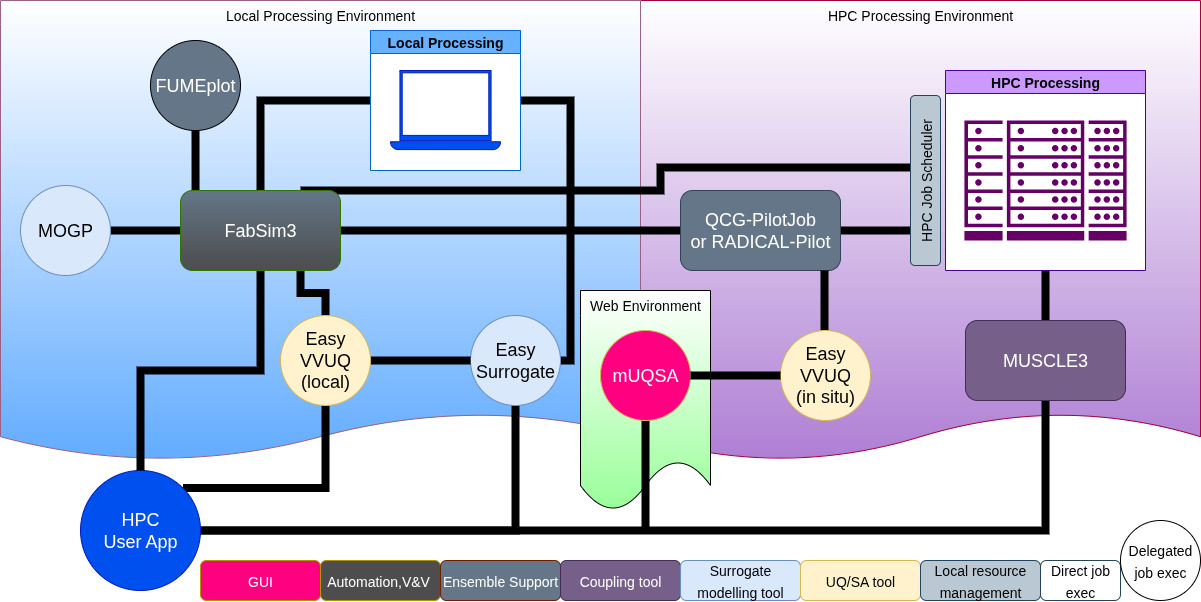

<p align="center">
    <strong>Figure 1.</strong> High-level architecture of the SEAVEA toolkit showing the interaction between local computing resources, HPC systems, workflow automation, uncertainty quantification, and simulation execution tools.
</p>

Figure 1 provides an overview of the SEAVEA ecosystem and how its components work together to support scientific computing workflows. The architecture is divided into a **Local Processing Environment** (left) and an **HPC Processing Environment** (right).

Within the local environment, researchers define simulation experiments, configure uncertain parameters, and perform uncertainty quantification using tools such as **EasyVVUQ**. **FabSim3** acts as the central workflow automation framework, coordinating simulation execution, managing files, and connecting local resources to remote HPC systems.

For large-scale simulation studies, workflows can be executed on HPC resources using **QCG-PilotJob** or **RADICAL-Pilot**, which efficiently manage large ensembles of simulation tasks within a single HPC allocation. These tasks are then scheduled and executed on the HPC cluster.

The broader SEAVEA ecosystem also includes additional components for surrogate modelling (EasySurrogate, MOGP Emulator), multiscale model coupling (MUSCLE3), uncertainty quantification portals (mUQSA), and visualisation (FUMEplot). These components are included in the architecture diagram to illustrate the full capabilities of SEAVEA; however, they are outside the scope of this introductory tutorial. 

## Components Used in this Tutorial

This tutorial focuses on the workflow formed by **EasyVVUQ**, **FabSim3**, and **QCG-PilotJob**, which together enable researchers to define uncertainty studies, automate simulation execution, and efficiently run large ensembles on local or HPC resources.


| Component        | Description                                                                                                                                              |
| ---------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **EasyVVUQ**     | Defines uncertain parameters, generates samples, manages simulation campaigns, and performs uncertainty quantification and sensitivity analysis.         |
| **FabSim3**      | Automates workflow execution, file transfer, and job management across local and HPC systems.                                                            |
| **QCG-PilotJob** | Efficiently executes large ensembles of simulation tasks within a single HPC allocation, reducing scheduler overhead and improving resource utilisation. |

## Environment Set-up Instructions

### Prerequisites

Before running this notebook:

- Create a Python 3.10 virtual environment.
- Install `requirements.txt`.
- Install and configure FabSim3, including creation of `machines_user.yml`.
- Install Flee and the FabFlee plugin.
- Confirm that the Mali configuration is available.

> This notebook uses Bash cells and must be run in Linux, WSL, Git Bash,
> Colab, or a Linux-based Jupyter environment.

### Links

Please refer to the following links for the corresponding components setup to be able to follow this tutorial.

FabSim3 installation (The installation process creates the
required fabsim/deploy/machines_user.yml file) - https://fabsim3.readthedocs.io/en/latest/installation/
<br>
EasyVVUQ installation - https://easyvvuq.readthedocs.io/en/dev/installation.html#id1
<br>
QCG-PilotJob installation - https://qcg-pilotjob.readthedocs.io/en/develop/installation.html
<br>
Flee installation - https://flee.readthedocs.io/en/master/Installation_and_Testing/
<br>
FabFlee Plugin - https://fabsim3.readthedocs.io/en/latest/plugins/


## Tutorial Problem Focus

This tutorial demonstrates how the SEAVEA components work together to support the simulation, validation, uncertainty quantification, and efficient execution of forced-migration models.

The primary demonstration uses the **Mali conflict scenario**, with additional examples from **Burundi, South Sudan, and the Central African Republic**.

The tutorial covers:

- Simulating refugee movements and camp populations using Flee.
- Automating simulation workflows and result collection with FabSim3.
- Comparing predicted camp populations with historical UNHCR data.
- Automatically validating multiple conflict scenarios.
- Investigating uncertain movement assumptions, including `max_move_speed` and `max_walk_speed`.
- Measuring total prediction error.
- Calculating Sobol sensitivity indices with EasyVVUQ.
- Executing simulation ensembles concurrently with QCG-PilotJob.

Together, these components provide an integrated workflow for examining how modelling assumptions affect forced-migration predictions while reducing the effort and computational cost of running large simulation ensembles.

## Table of Contents

- [Environment Set-up Instructions](#environment-set-up-instructions)
  - [Prerequisites](#prerequisites)
  - [Links](#links)
  - [Tutorial Problem Focus](#tutorial-problem-focus)

- [Set-up Instructions](#set-up-instructions)
  - [Windows / WSL2 Setup](#windows--wsl2-setup)
  - [macOS Setup](#macos-setup)
  - [Clone Repositories](#clone-repositories)
  - [SSH Key Setup](#ssh-key-setup)

- [FabSim3 Introduction](#fabsim3-introduction)
  - [Dependencies](#dependencies)
  - [Configure FabSim3](#configure-fabsim3)
  - [Install FabSim3](#install-fabsim3)
  - [Configure machines_user.yml](#configure-machines_useryml)
  - [Add FabSim3 to PATH and PYTHONPATH](#add-fabsim3-to-path-and-pythonpath)

- [Migration Modelling with Flee and FabFlee](#migration-modelling-with-flee-and-fabflee)
  - [Add Flee Location to machines_user.yml](#add-flee-location-to-machines_useryml)
  - [Verify Flee and FabFlee](#verify-flee-and-fabflee)
  - [Configure FabFlee Machine Settings](#configure-fabflee-machine-settings)
  - [Install Required Python Modules](#install-required-python-modules)
  - [Inspect the Mali Scenario](#inspect-the-mali-scenario)
  - [Run a Baseline Mali Simulation](#run-a-baseline-mali-simulation)
  - [Note Submitted Job Directory](#note-submitted-job-directory)
  - [Fetch Simulation Results](#fetch-simulation-results)
  - [Plot Simulation Output](#plot-simulation-output)
  - [Compare Predictions with UNHCR Data](#compare-predictions-with-unhcr-data)

- [EasyVVUQ Introduction](#easyvvuq-introduction)
  - [Key Capabilities](#key-capabilities)
  - [Role in the SEAVEA Workflow](#role-in-the-seavea-workflow)
  - [EasyVVUQ Components](#easyvvuq-components)
  - [Workflow Overview](#workflow-overview)
  - [Install EasyVVUQ into FabSim3 Environment](#install-easyvvuq-into-fabsim3-environment)
  - [Import EasyVVUQ and Chaospy](#import-easyvvuq-and-chaospy)
  - [Read FabFlee Uncertainty Configuration](#read-fabflee-uncertainty-configuration)
  - [Parameter Exploration](#parameter-exploration)
  - [Create Chaospy Distributions](#create-chaospy-distributions)
  - [Create EasyVVUQ Sampler](#create-easyvvuq-sampler)
  - [Generate and Execute EasyVVUQ Ensemble](#generate-and-execute-easyvvuq-ensemble)
  - [Inspect Encoded Flee Configurations](#inspect-encoded-flee-configurations)
  - [Decode and Analyse Ensemble Results](#decode-and-analyse-ensemble-results)
  - [Display and Interpret Sensitivity Results](#display-and-interpret-sensitivity-results)

- [QCG-PilotJob: Running Large Ensembles on HPC](#qcg-pilotjob-running-large-ensembles-on-hpc)
  - [What QCG-PilotJob Adds](#what-qcg-pilotjob-adds)
  - [HPC Prerequisites](#hpc-prerequisites)
  - [Install/check QCG-PilotJob Locally](#installcheck-qcg-pilotjob-locally)
  - [Local QCG-PilotJob Smoke Test](#local-qcg-pilotjob-smoke-test)

- [Configure the HPC Target](#configure-the-hpc-target)
  - [Create Terminal Script](#create-terminal-script)
  - [Run ARCHER2 Connection Check from Terminal](#run-archer2-connection-check-from-terminal)
  - [Create Demo Folder on ARCHER2](#create-demo-folder-on-archer2)
  - [Copy QCG Smoke-Test Files to ARCHER2](#copy-qcg-smoke-test-files-to-archer2)
  - [Submit QCG Smoke Test](#submit-qcg-smoke-test)
  - [Check Job Queue](#check-job-queue)
  - [Inspect Output](#inspect-output)
  - [Optional FabSim3 QCG Ensemble Submission](#optional-fabsim3-qcg-ensemble-submission)

# Set-up Instructions



#### For Windows (WSL2)
The recommended approach on Windows is to use Windows Subsystem for Linux (WSL2).

> Please note to run the following commands in a PowerShell terminal with administrator privileges.

##### Install WSL

Open PowerShell as Administrator and run:

In [ ]:
%%bash
wsl --install

Restart your machine if prompted and complete the Ubuntu installation.

Verify the installation:

In [ ]:
%%bash
wsl

##### Install Required System Packages

Inside the Ubuntu terminal:

In [ ]:
%%bash
sudo apt update 
sudo apt install git openssh-server rsync python3 python3-venv python3-pip

#### For macOS

Install Homebrew if it is not already installed.

Install the required dependencies:

In [ ]:
%%bash

brew install git python rsync openssh

### Clone the Repositories

Create a workspace directory:

In [ ]:
%%bash

mkdir -p ~/github 
cd ~/github

Clone the required repositories:

In [ ]:
%%bash

git clone https://github.com/djgroen/FabSim3.git
git clone https://github.com/djgroen/flee.git

### Setup ssh key

To setup ssh connection for executing jobs on localhost, simply run:

In [ ]:
%%bash

if [ ! -f ~/.ssh/id_rsa ]; then
    ssh-keygen -t rsa -N "" -f ~/.ssh/id_rsa
else
    echo "SSH key already exists"
fi
cat ~/.ssh/id_rsa.pub >> ~/.ssh/authorized_keys
chmod og-wx ~/.ssh/authorized_keys
ssh-keyscan -H localhost >> ~/.ssh/known_hosts

# FabSim3 Introduction

### Dependencies

FabSim3 relies strongly on the following Python modules:

- [Fabric](http://www.fabfile.org) (shown to work with versions 1.5.3 and 1.10.0), 
- [PyYAML](https://pypi.org/project/PyYAML/) (any version), 
- [ruamel.yaml](https://pypi.org/project/ruamel.yaml/)
- [numpy](https://numpy.org/install/) and
- [cryptography](https://pypi.org/project/cryptography/).

In [ ]:
%%bash

# Install required Python modules
pip3 install ruamel.yaml rich

Alternatively, these dependencies are also marked down in the `requirements.txt` file, as

`fabric3==1.13.1.post1, 
 pyyaml, 
 pytest, 
 pytest-pep8, 
 ruamel.yaml, 
 numpy, 
 cryptography`
 
To install requitements.txt, simply run the following:

In [ ]:
%%bash

# Make sure you provide the correct full path to the FabSim3 repository
pip install -r /full/path/to/FabSim3/requirements.txt

### Configure FabSim3
Navigate to the FabSim3 directory:

In [ ]:
%%bash

cd ~/github/FabSim3 
python3 configure_fabsim.py

### Intalling FabSim3 

To install [FabSim3](https://github.com/djgroen/FabSim3), clone the repository using:

In [ ]:
%%bash

if [ ! -d "FabSim3" ]
then
    git clone https://github.com/djgroen/FabSim3
    echo "FabSim3 rep cloned in -> " $PWD
else
    git -C FabSim3 pull
    echo "updating FabSim3 rep cloned in -> " $PWD
fi

### Configure `machine_user.yml` file

To set personal configurations, copy `machines_user_example.yml` as `machines_user.yml` in the `FabSim3/fabsim/deploy` folder and run the following sequence of commands, which will change `localhost:` configurations:

In [ ]:
%%bash
set -e

FABSIM_ROOT="$(cd .. && pwd)/FabSim3"
MACHINES_FILE="$FABSIM_ROOT/fabsim/deploy/machines_user.yml"

if [ ! -f "$MACHINES_FILE" ]; then
    echo "Error: FabSim3 is not configured. Complete the linked installation guide."
    exit 1
fi

echo "FabSim3 configuration found: $MACHINES_FILE"

### Add FabSim3 to your PATH and PYTHONPATH

To add FabSim3 executable file to system `PATH` and setup `PYTHONPATH`:

In [ ]:
import os
import sys

# print(os.environ['PATH'])
sys.path.insert(0,  r'%s/FabSim3/fabsim/bin' %(os.getcwd()))
sys.path.insert(0,  r'%s/FabSim3/fabsim' %(os.getcwd()))
os.environ['PATH']=r'%s/FabSim3/fabsim/bin' %(os.getcwd())+os.pathsep+os.environ['PATH']

# Test if fabsim command is availble
!which fabsim

### Migration Modelling with Flee and FabFlee

In this tutorial, we use two related but separate tools: **Flee** and **FabFlee**.

**Flee** is the migration simulation model. It is an agent-based modelling toolkit written in Python for simulating the movement of displaced people between geographical locations, such as conflict locations, towns, and camps. For more detail, see the [Flee documentation](https://flee.readthedocs.io/en/latest/).

**FabFlee** is not the simulation model itself. It is a FabSim3 plugin that connects FabSim3 to Flee. FabFlee automates the construction, execution, and analysis of Flee simulations by providing ready-made FabSim3 commands for running single simulations, ensembles, replicas, and sensitivity analysis workflows.

In short:

| Tool | Role in this tutorial |
|---|---|
| **Flee** | The agent-based migration model being executed. |
| **FabFlee** | The FabSim3 plugin used to automate and manage Flee simulation workflows. |

We installed Flee earlier by cloning the Flee repository. FabFlee is installed separately as a FabSim3 plugin.

> A FabSim3-based FabFlee plugin provides an environment for researchers and organisations to construct and modify simulations, instantiate and execute multiple runs for different policy decisions, as well as to validate and visualise the obtained results against the existing data.

To install FabFlee, run `install_plugin` function using:

In [ ]:
%%bash

fabsim localhost install_plugin:FabFlee

#### Adding the Flee directory location to your machine_user.yml file

Since FabFlee is a plugin for the Flee simulation code, add the current location of the Flee directory to the `machines_user.yml` configuration file:

In [ ]:
!sed -i  "s#<PATH_TO_FLEE>#$PWD/flee#g" FabSim3/plugins/FabFlee/machines_FabFlee_user.yml

To view changes in `machines_user.yml`, simply run the following

In [ ]:
machines_user_yml = yaml.load(open("FabSim3/plugins/FabFlee/machines_FabFlee_user.yml"), Loader=yaml.FullLoader)

print(yaml.dump({'localhost': machines_user_yml['localhost']}))

### Verify Flee and FabFlee

This check confirms that the Flee model and its FabSim3 plugin are available before any simulation is launched.

Expected folder layout (recommended):

```text
parent-folder/
├── SEAVEA-tutorials/
├── FabSim3/
└── flee/
```

The verification cell uses one directory above the notebook working directory (`../`) as the parent folder. If your repositories are stored in a different location, update the paths in the cell accordingly.

In [ ]:
%%bash
set -e

ROOT="$(cd .. && pwd)"
FLEE_ROOT="$ROOT/flee"
FABFLEE_ROOT="$ROOT/FabSim3/plugins/FabFlee"

if [ -d "$FLEE_ROOT" ]; then
    echo "Flee found: $FLEE_ROOT"
else
    echo "Flee not found: $FLEE_ROOT"
    exit 1
fi

if [ -d "$FABFLEE_ROOT" ]; then
    echo "FabFlee plugin found: $FABFLEE_ROOT"
else
    echo "FabFlee plugin not found: $FABFLEE_ROOT"
    exit 1
fi

### Configure FabFlee machine settings

After installing the FabFlee plugin, create a user-specific FabFlee config file from the example:.

In [ ]:
%%bash

FABSIM_ROOT="$HOME/github/FabSim3"
FABFLEE_ROOT="$FABSIM_ROOT/plugins/FabFlee"

cp "$FABFLEE_ROOT/machines_FabFlee_user_example.yml" \
   "$FABFLEE_ROOT/machines_FabFlee_user.yml"

Replace the placeholder path with the real location of your cloned Flee repository.

In [ ]:
%%bash

FABSIM_ROOT="$HOME/github/FabSim3"
FABFLEE_CONFIG="$FABSIM_ROOT/plugins/FabFlee/machines_FabFlee_user.yml"
FLEE_ROOT="$HOME/github/flee"

sed -i "s#<PATH_TO_FLEE>#$FLEE_ROOT#g" "$FABFLEE_CONFIG"

Print the updated configuration so users can confirm the Flee path is correct.

In [ ]:
%%bash

FABSIM_ROOT="$HOME/github/FabSim3"
FABFLEE_CONFIG="$FABSIM_ROOT/plugins/FabFlee/machines_FabFlee_user.yml"

cat "$FABFLEE_CONFIG"

Load the config in Python and display the localhost settings.

In [ ]:
from pathlib import Path
import yaml

fabflee_config = Path.home() / "github" / "FabSim3" / "plugins" / "FabFlee" / "machines_FabFlee_user.yml"

with open(fabflee_config) as f:
    config = yaml.safe_load(f)

config["localhost"]

### Installing required python modules for Flee 

To install all required Python packages, simply install:

In [ ]:
!pip install pandas matplotlib numpy mpi4py

### Inspect the Mali Scenario

The Mali configuration contains the migration network, conflict data, camp locations, simulation settings, and historical observations used for validation.

In [ ]:
%%bash
set -e

FABSIM_ROOT="$(cd .. && pwd)/FabSim3"

MALI_SCENARIO="mali2012"
MALI_CONFIG="$FABSIM_ROOT/plugins/FabFlee/config_files/$MALI_SCENARIO"

[ -d "$MALI_CONFIG" ] || { echo "Error: Mali configuration was not found at $MALI_CONFIG"; exit 1; }

echo "Mali configuration: $MALI_CONFIG"
find "$MALI_CONFIG" -maxdepth 2 -type f | sed -n '1,20p'

### Run a Baseline Mali Simulation

There are 4 different ways to execute multiscale migration simulations in FabFlee:

* Single-model execution
<br>
* Ensemble execution
<br>
* Replica execution
<br>
* Coupled execution

Each method has its unique purpose. The single-model execution can be easily performed on a laptop and instantly provide an overview to users. The ensemble execution may be useful for those who run multiple simulation instances simultaneously. The replica execution could be an interesting option for those who run simulations at once with identical inputs for analysis. The coupled execution can couple migration simulation with conflict evolution models in the context of multiscale uncertainty quantification (UQ).

#### Purposes of Demonstration

To execute FabFlee job on a localhost, execute one of the conflict instances using `flee` function in `FabSim3/plugins/FabFlee/config_files`, such as Mali (mali, simulation period of 300 days), Burundi (burundi, simulation period of 396 days), South Sudan (ssudan, simulation period of 604 days) and Central African Republic (car, simulation period of 820 days). 

For illustration purposes, the conflict scenario of Mali is executed to obtain the simulation output for a simulation period of 50 days, which can be changed up to 300 days.

In [ ]:
%%bash

fabsim localhost sflee:mali2012,simulation_period=50

### Note the Submitted Job Directory

FabSim3 prints the path of the generated job script when it submits a run. Keep this path because it identifies the run that was executed.

Example:
```bash
Submitted job script:
/home/path/FabSim3/localhost_exe/FabSim/results/mali2012_localhost_1/mali2012_localhost_1.sh
```

The run directory is the parent folder of that script:

```bash
/home/path/FabSim3/localhost_exe/FabSim/results/mali2012_localhost_1
```

After fetching results, the corresponding local results directory is usually:

```bash
/home/path/FabSim3/results/mali2012_localhost_1
```

So for later plotting, use the local fetched results path, not the job script path:

In [ ]:
from pathlib import Path

RUN_NAME = "mali2012_localhost_1"
RESULT_DIR = Path.home() / "github" / "FabSim3" / "results" / RUN_NAME

RESULT_DIR

So yes: keep track of mali2012_localhost_1, but later code should usually use:

#### Fetching the simulation results to `FabSim3/results` directory

After the job has finished, a message will be printed indicating where the output data resides. To fetch and copy the obtained results to `FabSim3/results` directory, simply execute:

In [ ]:
%%bash
fabsim localhost fetch_results

### Plotting the simulation output

After fetching the simulation results, analyse and interpret simulation output by plotting graphs for individual camps comparing simulation output and UNHCR data, as well as average relative difference graph for the simulated conflict situation.

In [ ]:
%%bash

cd FabSim3

RESULT_NAME="mali2012_localhost_1"  # change this to your result directory name

fabsim localhost plot_output:${RESULT_NAME},out

To list generated plots, run the following command

In [ ]:
%%bash
FABSIM_RESULTS="${FABSIM_RESULTS:-$HOME/github/FabSim3/results}"
SCENARIO="${SCENARIO:-mali2012}"
MACHINE="${MACHINE:-localhost}"

RESULT_DIR=$(find "$FABSIM_RESULTS" -maxdepth 1 -type d \
  -name "${SCENARIO}_${MACHINE}_*" \
  -printf "%T@ %p\n" | sort -nr | head -n 1 | cut -d' ' -f2-)

if [ -z "$RESULT_DIR" ]; then
  echo "No result directory found for ${SCENARIO}_${MACHINE}_* in $FABSIM_RESULTS"
  exit 1
fi

echo "Latest result: $RESULT_DIR"

if [ -d "$RESULT_DIR/out" ]; then
  find "$RESULT_DIR/out" -maxdepth 1 -type f
else
  echo "No out directory found in $RESULT_DIR"
fi

In [ ]:
%%bash
FABSIM_RESULTS="${FABSIM_RESULTS:-$HOME/github/FabSim3/results}"
SCENARIO="${SCENARIO:-mali2012}"
MACHINE="${MACHINE:-localhost}"

RESULT_DIR=$(find "$FABSIM_RESULTS" \
  -maxdepth 1 -type d -name "${SCENARIO}_${MACHINE}_*" \
  -printf "%T@ %p\n" | sort -nr | head -n 1 | cut -d" " -f2-)

if [ -z "$RESULT_DIR" ]; then
  echo "No result directory found matching: ${SCENARIO}_${MACHINE}_*"
  echo "Searched in: $FABSIM_RESULTS"
  exit 1
fi

echo "Result directory: $RESULT_DIR"

if [ ! -d "$RESULT_DIR/out" ]; then
  echo "No output directory found: $RESULT_DIR/out"
  exit 1
fi

echo "Output contents:"
find "$RESULT_DIR/out" -type f

To view generated plots, simply run:

In [ ]:
from pathlib import Path
from IPython.display import Image, display

# Change this to one of the result directories printed above
RESULT_DIR = Path("/home/path/FabSim3/results/mali2012_localhost_1")

# Change this if you want a different camp/image
IMAGE_PATH = RESULT_DIR / "out" / "camps" / "Abala.png"

display(Image(filename=str(IMAGE_PATH)))

### Compare Predictions with UNHCR Data

FabFlee compares simulated populations at individual camps with historical UNHCR observations. The generated plots show camp-level agreement and prediction error over time.

In [ ]:
%%bash
set -e

export MPLBACKEND=Agg

FABSIM_ROOT="$(cd .. && pwd)/FabSim3"
FABSIM_PYTHON="$FABSIM_ROOT/VirtualEnv/bin/python"

LATEST_RESULT=$(
    find "$FABSIM_ROOT/results" \
        -maxdepth 1 \
        -type d \
        -name "mali2012_localhost_*" \
        ! -name "*_SA_*" \
        -printf "%T@ %p\n" |
    sort -nr |
    head -n 1 |
    cut -d" " -f2-
)

if [ -z "$LATEST_RESULT" ]; then
    echo "No fetched Mali result found. Run and fetch the baseline first."
    exit 1
fi

RUN_NAME="$(basename "$LATEST_RESULT")"

cd "$FABSIM_ROOT"

echo "Generating validation plots for: $RUN_NAME"

"$FABSIM_PYTHON" -X utf8 ./fabsim/bin/fabsim \
    localhost "plot_output:${RUN_NAME},out"

In [ ]:
from pathlib import Path
from IPython.display import Image, display

fabsim_root = (Path.cwd().parent / "FabSim3").resolve()

result_directories = sorted(
    [
        path
        for path in (fabsim_root / "results").glob(
            "mali2012_localhost_*"
        )
        if "_SA_" not in path.name
    ],
    key=lambda path: path.stat().st_mtime,
    reverse=True,
)

if not result_directories:
    raise FileNotFoundError(
        "No fetched Mali result found. Run the baseline simulation first."
    )

result_directory = result_directories[0]
plot_directory = result_directory / "out"

print(f"Validation results: {result_directory.name}\n")

# Display two representative camp comparisons.
camp_plots = sorted((plot_directory / "camps").glob("*.png"))

for plot in camp_plots[:2]:
    print(f"Camp comparison: {plot.stem}")
    display(Image(filename=str(plot)))

# Display aggregate prediction-error plots.
error_plots = [
    plot_directory / "errors" / "error_comparison.png",
    plot_directory / "errors" / "error.png",
]

for plot in error_plots:
    if plot.is_file():
        print(f"Error analysis: {plot.name}")
        display(Image(filename=str(plot)))

# EasyVVUQ Introduction

[EasyVVUQ](https://easyvvuq.readthedocs.io/) is a Python library that simplifies **Uncertainty Quantification (UQ)** and **Sensitivity Analysis (SA)** for scientific simulations. It provides a user-friendly interface for defining uncertain parameters, generating samples, executing simulation campaigns, and analysing results.

### Key Capabilities

- **Parameter Definition**: Specify uncertain input parameters and their probability distributions.
- **Sampling**: Generate parameter samples using various methods (Monte Carlo, Latin Hypercube, Polynomial Chaos, etc.).
- **Campaign Management**: Organize and execute simulation ensembles systematically.
- **Sensitivity Analysis**: Calculate Sobol indices and other sensitivity measures to identify which uncertain parameters most significantly affect model outputs.
- **Uncertainty Quantification**: Compute statistical moments and probability distributions of model predictions.

### Role in SEAVEA Workflow

In this tutorial, EasyVVUQ works with FabSim3 and FabFlee to:

1. Define uncertain Flee parameters such as `max_move_speed` and `max_walk_speed`.
2. Generate parameter samples using polynomial chaos expansion.
3. Create a simulation campaign with one Flee run per sample.
4. Analyse the ensemble results to calculate how parameter uncertainty propagates to prediction error.

This integrated approach enables researchers to understand the sensitivity of forced-migration predictions to modelling assumptions without manually configuring hundreds of individual simulations.

### EasyVVUQ Components

EasyVVUQ works through a series of interconnected components that manage the uncertainty quantification workflow. Each component plays a specific role in transforming uncertain parameters into actionable insights about simulation sensitivity.

| Component | What it means | Your FLEE example |
| --- | --- | --- |
| **Parameter distributions** | Define uncertain inputs | `max_move_speed`, `max_walk_speed` |
| **Sampler** | Chooses parameter combinations | Different speed values to test |
| **Encoder** | Writes parameter values into input files | Creates FLEE input/config file |
| **Decoder** | Reads simulation output | Extracts total error / camp population |
| **Analysis** | Interprets results | Sobol sensitivity indices |

### Workflow Overview

1. **Parameter Distributions**: You specify which input parameters are uncertain and their probability distributions (e.g., `max_move_speed` ranges from 2 to 4 km/day).

2. **Sampler**: EasyVVUQ generates parameter samples using methods such as Polynomial Chaos Expansion, Monte Carlo, or Latin Hypercube Sampling. Each sample represents a unique combination of uncertain parameters.

3. **Encoder**: For each sample, the encoder converts parameter values into FLEE-compatible input files and configuration settings.

4. **Simulation Execution**: FLEE runs with each encoded parameter set, producing camp population time series and other outputs.

5. **Decoder**: After simulation, the decoder extracts relevant outputs (e.g., total prediction error, camp populations) from FLEE results.

6. **Analysis**: Statistical methods compute sensitivity indices (Sobol indices), uncertainty bounds, and other measures that quantify how parameter uncertainty propagates to model predictions.

This modular design allows EasyVVUQ to work with any simulation tool by simply changing the encoder and decoder while keeping the sampling and analysis components generic.

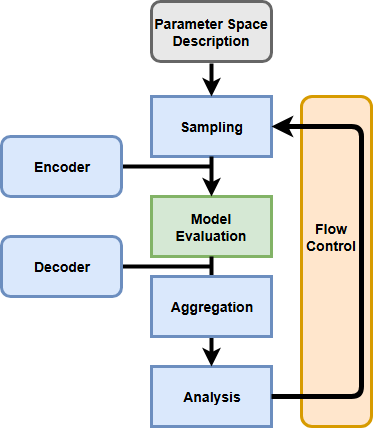


#### Install EasyVVUQ into FabSim3’s environment
The notebook launches FabSim3 using its own interpreter, so EasyVVUQ must exist there:

In [ ]:
%%bash
../FabSim3/VirtualEnv/bin/python -m pip install easyvvuq==1.3 chaospy

### Importing EasyVVUQ and Chaospy

**EasyVVUQ** is the core library for uncertainty quantification and sensitivity analysis. It provides the tools to define parameter distributions, manage sampling campaigns, and calculate sensitivity indices like Sobol indices.

**Chaospy** is a polynomial chaos expansion library that EasyVVUQ uses for advanced sampling and uncertainty propagation. It enables efficient parameter sampling and surrogate modelling through polynomial chaos methods.

Together, these libraries enable the automated generation of parameter samples and the statistical analysis of how uncertain inputs propagate through the Flee migration model.

In [ ]:
import easyvvuq as uq
import chaospy as cp

### Read the Real FabFlee Uncertainty Configuration

The uncertain parameters are defined in FabFlee’s `flee_SA_config.yml` file. This is the same configuration used by the real EasyVVUQ sensitivity-analysis workflow.

The cell below reads the selected parameters and their ranges directly from that file. This ensures that the parameter values displayed in the notebook match those used to generate and execute the Flee simulation ensemble.

In [ ]:
from pathlib import Path
import yaml

fabsim_root = (Path.cwd().parent / "FabSim3").resolve()
sa_config_file = (
    fabsim_root
    / "plugins"
    / "FabFlee"
    / "SA"
    / "flee_SA_config.yml"
)

with sa_config_file.open(encoding="utf-8") as stream:
    sa_config = yaml.safe_load(stream)

flee_parameters = {}

for name in sa_config["selected_vary_parameters"]:
    lower, upper = sa_config["vary_parameters_range"][name]["range"]
    flee_parameters[name] = {
        "min": lower,
        "max": upper,
        "unit": "km/day",
    }

print(f"Configuration: {sa_config_file}")

for name, spec in flee_parameters.items():
    print(
        f"{name}: Uniform({spec['min']}, {spec['max']}) "
        f"{spec['unit']}"
    )

##### Parameter Exploration

To perform sensitivity analysis on input parameters of Flee, we mainly focus on two sampler examples, namely (a) SCSampler (Stochastic Collocation sampler) and (b) PCESampler (Polynomial Chaos Expansion sampler), that are available in EasyVVUQ. The configuration for SA can be set in `flee_SA_config.yml` located in `FabSim3/plugin/FabFlee` directory. All required configurations for FabFlee SA, such as sampler name, varying input parameters, and the number of polynomial order, are loaded from `flee_SA_config.yml` file. To illustrate, we present an example of two `config` parameters below, namely (`max_move_speed` and `max_walk_speed`):


In [ ]:
from pathlib import Path
import yaml

config_path = (
    Path.cwd().parent
    / "FabSim3"
    / "plugins"
    / "FabFlee"
    / "SA"
    / "flee_SA_config.yml"
)

with config_path.open(encoding="utf-8") as file:
    flee_sa_config = yaml.safe_load(file)

summary = {
    "selected_vary_parameters":
        flee_sa_config["selected_vary_parameters"],
    "distribution_type":
        flee_sa_config["distribution_type"],
    "polynomial_order":
        flee_sa_config["polynomial_order"],
    "sampler_name":
        flee_sa_config["sampler_name"],
}

print(yaml.safe_dump(summary, sort_keys=False))

### Create the Chaospy Distributions

EasyVVUQ uses Chaospy distributions to represent uncertain inputs. The distributions below are created from the parameter ranges read from FabFlee’s real sensitivity-analysis configuration.

These distributions will be passed to the EasyVVUQ sampler in the next step.

In [ ]:
distribution_type = sa_config["distribution_type"]

if distribution_type == "Uniform":
    distribution_class = cp.Uniform
elif distribution_type == "DiscreteUniform":
    distribution_class = cp.DiscreteUniform
else:
    raise ValueError(f"Unsupported distribution: {distribution_type}")

vary = {
    name: distribution_class(spec["min"], spec["max"])
    for name, spec in flee_parameters.items()
}

vary

### Create the EasyVVUQ Sampler

The sampler chooses the parameter combinations used in the sensitivity study. Its type, polynomial order, and quadrature settings are read from FabFlee’s real configuration.

This cell previews the same sampling strategy that `flee_init_SA` will use when creating the real simulation ensemble.

In [ ]:
sampler_name = sa_config["sampler_name"]

if sampler_name == "SCSampler":
    sampler = uq.sampling.SCSampler(
        vary=vary,
        polynomial_order=sa_config["polynomial_order"],
        quadrature_rule=sa_config["quadrature_rule"],
        growth=sa_config["growth"],
        sparse=sa_config["sparse"],
        midpoint_level1=sa_config["midpoint_level1"],
        dimension_adaptive=sa_config["dimension_adaptive"],
    )

elif sampler_name == "PCESampler":
    sampler = uq.sampling.PCESampler(
        vary=vary,
        polynomial_order=sa_config["polynomial_order"],
        rule=sa_config["quadrature_rule"],
        sparse=sa_config["sparse"],
        growth=sa_config["growth"],
    )

else:
    raise ValueError(f"Unsupported EasyVVUQ sampler: {sampler_name}")

print(f"Sampler: {sampler_name}")
print(f"Polynomial order: {sa_config['polynomial_order']}")
print(sampler)

The following cell displays the parameter combinations generated by the configured sampler. These provide a preview of the samples that FabFlee will regenerate when `flee_init_SA` creates the real EasyVVUQ campaign.

In [ ]:
def clean_sample(sample):
    """
    Convert EasyVVUQ/NumPy values into standard Python values
    so the generated parameter combinations are easy to display.
    """
    return {
        key: value.item() if hasattr(value, "item") else value
        for key, value in sample.items()
    }


preview_parameter_sets = [
    clean_sample(sample)
    for sample in sampler
]

print(
    f"EasyVVUQ generated {len(preview_parameter_sets)} "
    "parameter sets:\n"
)

for index, sample in enumerate(preview_parameter_sets):
    print(f"Sample {index}: {sample}")

### Generate and Execute the Real EasyVVUQ Ensemble

FabFlee’s `flee_init_SA` task creates an EasyVVUQ campaign from the configuration examined above. For each sampled parameter combination, EasyVVUQ generates a `simsetting.yml` file and FabSim3 executes a real Mali Flee simulation.

Each simulation produces an `out.csv` file containing model predictions and the total prediction error. A 30-day simulation period is used to keep the tutorial runtime manageable.

In [ ]:
%%bash
set -e

export MPLBACKEND=Agg

FABSIM_ROOT="$(cd .. && pwd)/FabSim3"
FABSIM_PYTHON="$FABSIM_ROOT/VirtualEnv/bin/python"

if [ ! -x "$FABSIM_PYTHON" ]; then
    echo "FabSim3 Python environment not found: $FABSIM_PYTHON"
    exit 1
fi

cd "$FABSIM_ROOT"

"$FABSIM_PYTHON" -X utf8 ./fabsim/bin/fabsim \
    localhost flee_init_SA:mali2012,simulation_period=30

### Inspect the Encoded Flee Configurations

EasyVVUQ’s `GenericEncoder` creates one `simsetting.yml` file for each sampled parameter combination. FabFlee places these configurations in the Mali `SWEEP` directory before FabSim3 executes the ensemble.

The following cell reads the generated files and displays the movement parameters used by each Flee run. This confirms that the EasyVVUQ samples were passed into the real model.

In [ ]:
from pathlib import Path
import yaml

sweep_dir = (
    fabsim_root
    / "plugins"
    / "FabFlee"
    / "config_files"
    / "mali2012"
    / "SWEEP"
)

simsetting_files = sorted(sweep_dir.glob("run_*/simsetting.yml"))

if not simsetting_files:
    raise FileNotFoundError(
        "No encoded simsetting.yml files were found. "
        "Run Step 11 first."
    )

print(f"Found {len(simsetting_files)} encoded configurations:\n")

selected_parameters = sa_config["selected_vary_parameters"]

for simsetting_file in simsetting_files:
    with simsetting_file.open(encoding="utf-8") as stream:
        settings = yaml.safe_load(stream)

    move_rules = settings["move_rules"]
    sampled_values = {
        parameter: move_rules[parameter]
        for parameter in selected_parameters
    }

    print(f"{simsetting_file.parent.name}: {sampled_values}")

### Decode and Analyse the Real Ensemble Results

FabFlee’s `flee_analyse_SA` task performs the final EasyVVUQ stages. It fetches the `out.csv` file from every Flee run, uses EasyVVUQ’s `SimpleCSV` decoder to extract the `Total error` quantity of interest, and collates the results.

EasyVVUQ then calculates statistical measures and Sobol sensitivity indices. These indices show how strongly each uncertain movement parameter contributes to variation in Flee’s prediction error.

In [ ]:
%%bash
set -e

export MPLBACKEND=Agg

FABSIM_ROOT="$(cd .. && pwd)/FabSim3"
FABSIM_PYTHON="$FABSIM_ROOT/VirtualEnv/bin/python"

if [ ! -x "$FABSIM_PYTHON" ]; then
    echo "FabSim3 Python environment not found: $FABSIM_PYTHON"
    exit 1
fi

cd "$FABSIM_ROOT"

"$FABSIM_PYTHON" -X utf8 ./fabsim/bin/fabsim \
    localhost flee_analyse_SA:mali2012

### Display and Interpret the Sensitivity Results

The analysis produces first-order Sobol indices for each uncertain parameter. A larger index means that the parameter explains a greater proportion of the variation in Flee’s total prediction error.

The cell below reads the generated `sobols.yml` file, displays the mean sensitivity index for each parameter, and shows the plots created by FabFlee.

In [ ]:
from IPython.display import Image, display
import yaml

campaign_dir = (
    fabsim_root
    / "plugins"
    / "FabFlee"
    / "SA"
    / f"flee_SA_{sa_config['sampler_name']}_mali2012"
)

sobols_file = campaign_dir / "sobols.yml"

if not sobols_file.is_file():
    raise FileNotFoundError(
        "Sobol results were not found. Run Step 13 first."
    )

with sobols_file.open(encoding="utf-8") as stream:
    sobol_results = yaml.safe_load(stream)

campaign_info = sobol_results["campaign_info"]

print("Campaign:", campaign_info["name"])
print("Number of runs:", campaign_info["num_runs"])
print("Quantity of interest:", campaign_info["output_column"])
print("\nMean first-order Sobol indices:")

for parameter in sa_config["selected_vary_parameters"]:
    mean_index = sobol_results[parameter]["sobols_first_mean"]
    print(f"  {parameter}: {mean_index:.4f}")

print("\nGenerated analysis plots:")

for plot_file in sorted(campaign_dir.glob("*.png")):
    print(plot_file.name)
    display(Image(filename=str(plot_file)))

# QCG-PilotJob: Running Large Ensembles on HPC

The EasyVVUQ sensitivity study above creates many independent Flee simulations. That is ideal for parallel execution: each sample can run as a separate task, and the final analysis only needs the completed output files.

On a laptop, launching a small number of samples is fine. On an HPC system such as ARCHER2, a realistic study may require hundreds or thousands of runs. Submitting each run as a separate scheduler job is inefficient and creates avoidable queue overhead. QCG-PilotJob solves this by submitting one pilot allocation to the scheduler and then scheduling many smaller Flee tasks inside that allocation.

In this section we show two execution paths:

- a FabSim3/FabFlee route, where `PJ=True` asks FabFlee to use QCG-PilotJob for the ensemble or EasyVVUQ campaign;
- a direct QCG-PilotJob smoke test, useful for checking that the HPC allocation can start QCG tasks before launching the full migration workflow.

## What QCG-PilotJob Adds

QCG-PilotJob is a pilot-job layer. Instead of asking the HPC scheduler for one allocation per Flee run, it asks for one allocation and then manages many subordinate tasks within it.

For this tutorial workflow:

1. EasyVVUQ defines the uncertain Flee parameters and creates the sample set.
2. FabFlee generates one Flee configuration per sample.
3. FabSim3 stages the campaign to the target machine.
4. QCG-PilotJob schedules the sample runs inside the HPC allocation.
5. FabSim3 fetches results back, and the EasyVVUQ analysis step computes the Sobol indices and plots shown earlier.

This is the same scientific workflow as the local section above; QCG-PilotJob changes where and how the independent model evaluations are executed.

## HPC Prerequisites

Before running this section on ARCHER2 or another SLURM-based machine, make sure the following are available:

- an active HPC account and project budget/allocation;
- SSH key access from this machine to the HPC login node;
- a FabSim3 machine entry for the HPC system, for example `archer2`, in the FabSim3 machine configuration;
- FabFlee installed and configured on the remote side, including the path to the Flee repository;
- QCG-PilotJob available on the remote side, either as a system/module install or in the FabSim3-managed virtual environment;
- the same scenario name used earlier in this notebook, for example `mali2012`, available in FabFlee's `config_files` directory.

The remote commands below are deliberately dry-run by default. Set `RUN_REMOTE_COMMANDS = True` only when the FabSim3 machine entry and SSH access are ready.

### Install or Check QCG-PilotJob Locally

The local notebook environment only needs QCG-PilotJob for the smoke test and for inspecting the Python package. The real HPC campaign will use the QCG-PilotJob installation available on the remote machine.

In [ ]:
%%bash
python -m pip install --upgrade qcg-pilotjob

In [ ]:
from importlib.metadata import PackageNotFoundError, version
import shutil

try:
    print(f"QCG-PilotJob Python package: {version('qcg-pilotjob')}")
except PackageNotFoundError:
    print("QCG-PilotJob is not installed in this notebook environment yet.")

qcg_service = shutil.which("qcg-pm-service")
print("qcg-pm-service:", qcg_service or "not found on PATH")

### Local QCG-PilotJob Smoke Test

This small example checks that QCG-PilotJob can run a few independent tasks. It does not use Flee; it is only a quick confidence check before moving the same pilot-job idea to HPC.

In [ ]:
from pathlib import Path
import json

smoke_dir = Path("qcg_pilotjob_smoke")
smoke_dir.mkdir(exist_ok=True)

jobs = [
    {
        "request": "submit",
        "jobs": [
            {
                "name": "qcg_hello_1",
                "execution": {
                    "exec": "/bin/bash",
                    "args": ["-lc", "hostname; python3 --version"],
                    "stdout": "hello_1.out",
                    "stderr": "hello_1.err",
                },
            },
            {
                "name": "qcg_hello_2",
                "execution": {
                    "exec": "/bin/bash",
                    "args": ["-lc", "echo QCG task $QCG_PM_NNODES nodes $QCG_PM_NCORES cores"],
                    "stdout": "hello_2.out",
                    "stderr": "hello_2.err",
                },
            },
        ],
    },
]

jobs_file = smoke_dir / "jobs.json"
jobs_file.write_text(json.dumps(jobs, indent=2), encoding="utf-8")
print(jobs_file)

In [ ]:
%%bash

set -e

if command -v qcg-pm-service >/dev/null 2>&1; then
    rm -rf qcg_pilotjob_smoke/out

    qcg-pm-service \
        --wd qcg_pilotjob_smoke/out \
        --resources local \
        --nodes 1 \
        --show-progress \
        --file-path qcg_pilotjob_smoke/jobs.json

    find qcg_pilotjob_smoke/out \
        -maxdepth 3 \
        -type f \
        -name "hello_*.out" \
        -print \
        -exec cat {} \;
else
    echo "qcg-pm-service is not on PATH. Run the install cell above or use the HPC route below."
fi

## Configure the HPC Target

Adjust these values for your training account or project. `ARCHER2_MACHINE` must match the machine name known to FabSim3. The notebook uses `mali2012` because that is the scenario used in the local sections above.

In [ ]:
from pathlib import Path
import os
import shlex

ARCHER2_MACHINE = "archer2"  # FabSim3 machine name

# Change this to your own Archer2 username if you want to run the commands on Archer2.
ARCHER2_SSH = "username@login.archer2.ac.uk"  # real SSH login

ARCHER2_PROJECT = "ta237"
REMOTE_WORKDIR = "~/seavea-qcg-demo"
FLEE_SCENARIO = "mali2012"
SIMULATION_PERIOD = 50

FABSIM_ROOT = (Path.cwd().parent / "FabSim3").resolve()
FABSIM_PYTHON = FABSIM_ROOT / "VirtualEnv" / "bin" / "python"
FABSIM_SCRIPT = FABSIM_ROOT / "fabsim" / "bin" / "fabsim"
FLEE_ROOT = Path("/home/path/flee").resolve()

print("FabSim3 root:", FABSIM_ROOT)
print("FabSim3 Python:", FABSIM_PYTHON)
print("FabSim3 script:", FABSIM_SCRIPT)
print("Flee root:", FLEE_ROOT)
print("FabSim3 remote machine:", ARCHER2_MACHINE)
print("SSH target:", ARCHER2_SSH)

Creating a terminal script:

In [ ]:
script = f"""#!/usr/bin/env bash
set -euo pipefail

export PYTHONPATH="{FLEE_ROOT}:{FABSIM_ROOT}:${{PYTHONPATH:-}}"

echo "Checking SSH connection to ARCHER2..."
ssh {shlex.quote(ARCHER2_SSH)} hostname

echo
echo "Checking FabSim3 job status on ARCHER2..."
cd {shlex.quote(str(FABSIM_ROOT))}
{shlex.quote(str(FABSIM_PYTHON))} -X utf8 {shlex.quote(str(FABSIM_SCRIPT))} {shlex.quote(ARCHER2_MACHINE)} stat
"""

script_path = Path("run_archer2_check.sh")
script_path.write_text(script, encoding="utf-8")
script_path.chmod(0o755)

print(f"Created: {script_path}")
print("Run this in your VS Code terminal:")
print(f"bash {script_path}")

**In the terminal run:**

In [ ]:
%%bash

bash run_archer2_check.sh

>Below is the clean demo flow. Run all commands in this section directly in your VS Code terminal, not inside the notebook. This is important because ARCHER2 asks for an interactive TOTP code.

### Go to the tutorial folder
This puts you in the folder where the notebook generated the ARCHER2 helper files.

In [ ]:
cd full/path/to/github/SEAVEA-tutorials

#### Run the ARCHER2 connection check

**This checks:**
<br>
* SSH connection to ARCHER2
<br>
* FabSim3 status command for archer2

If ARCHER2 asks:

````bash
TOTP code:
````

enter your current authenticator code.

Run the notebook cell titled:

````bash
Optional: Direct ARCHER2 QCG-PilotJob Smoke Script
````

This creates:

````bash
qcg_pilotjob_archer2/jobs.json
qcg_pilotjob_archer2/submit_qcg_smoke.slurm
````

#### Create a demo folder on ARCHER2

This creates a remote folder on ARCHER2 where the QCG smoke-test files will be copied.

In [ ]:
%%bash

ssh username@login.archer2.ac.uk "mkdir -p ~/seavea-qcg-demo"

#### Copy the QCG smoke-test files to ARCHER2

This copies the generated QCG job file and SLURM submission script to ARCHER2.

In [ ]:
%%bash

scp qcg_pilotjob_archer2/jobs.json \
    qcg_pilotjob_archer2/submit_qcg_smoke.slurm \
    username@login.archer2.ac.uk:~/seavea-qcg-demo/

#### Submit the QCG smoke test on ARCHER2

This submits a small SLURM job. The job runs qcg-pm-service inside the ARCHER2 allocation and launches a few tiny hostname/date tasks.

In [ ]:
%%bash

ssh username@login.archer2.ac.uk \
    "cd ~/seavea-qcg-demo && sbatch submit_qcg_smoke.slurm"

#### Check the job queue

This shows whether your submitted job is queued, running, or finished.

In [ ]:
%%bash

ssh username@login.archer2.ac.uk "squeue -u username"

#### Inspect the output after the job finishes

This shows the SLURM output. You should see QCG progress messages and the outputs from the small test tasks.

In [ ]:
%%bash

ssh username@login.archer2.ac.uk \
    "cd ~/seavea-qcg-demo && ls -R && cat seavea-qcg-smoke.*.out"

#### Optional: Submit the FabSim3 QCG ensemble

Only run this if the direct QCG smoke test worked

This uses FabSim3 locally to install/check QCG on ARCHER2, submit a small Flee ensemble using PJ=True, and check job status.

In [ ]:
%%bash

# Ensure the below paths and environment variables are correct for your setup.

cd /home/path/FabSim3

export PYTHONPATH=/home/path/flee:/home/path/FabSim3:${PYTHONPATH:-}

VirtualEnv/bin/python -X utf8 fabsim/bin/fabsim archer2 install_app:QCG-PilotJob,venv=True

VirtualEnv/bin/python -X utf8 fabsim/bin/fabsim archer2 flee_ensemble:mali2012,N=20,simulation_period=50,PJ=True

VirtualEnv/bin/python -X utf8 fabsim/bin/fabsim archer2 stat